In [1]:
import pandas as pd
import numpy as np
model_data = pd.read_csv('coach.csv', index_col=[0])#3
test_data = pd.read_csv('ours.csv', index_col=[0])#4
# model_data=model_data.T
# test_data=test_data.T
# model_data = model_data.reset_index()
# test_data = test_data.reset_index()
# model_data= model_data.iloc[:, 2:]
# test_data= test_data.iloc[:,2 :]
# model_data.columns=range(len(model_data.columns))
# test_data.columns=range(len(test_data.columns))

model_data


,landmark,x,y,z
frame_number,,,,
0,NOSE,0.587037,0.368636,-0.028808
0,LEFT_EYE_INNER,0.589756,0.354170,-0.009998
0,LEFT_EYE,0.588707,0.353098,-0.010090
0,LEFT_EYE_OUTER,0.587685,0.351868,-0.010125
0,RIGHT_EYE_INNER,0.589423,0.354105,-0.059704
...,...,...,...,...
323,RIGHT_ANKLE,0.528967,0.843964,0.197576
323,LEFT_HEEL,0.482220,0.862516,-0.133948
323,RIGHT_HEEL,0.535784,0.861201,0.201454


In [2]:
import pandas as pd
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis

# 計算 DTW 距離
model_landmarks = model_data['landmark'].unique()
test_landmarks = test_data['landmark'].unique()

# 確保 Model 和 Test 的 Landmark 一致
assert set(model_landmarks) == set(test_landmarks), "Model 和 Test 的 Landmark 不一致！"

x_distance = []
for landmark in model_landmarks:
    model_sequence = model_data[model_data['landmark'] == landmark][['x', 'y', 'z']].values
    test_sequence = test_data[test_data['landmark'] == landmark][['x', 'y', 'z']].values

    model_sequence_flat = model_sequence.flatten()#三維資料壓成一維
    test_sequence_flat = test_sequence.flatten()

    # 計算 DTW 距離和對應的 warping 路徑
    distance, paths = dtw.warping_paths(model_sequence_flat, test_sequence_flat)

    # 將距離和路徑加入列表
    x_distance.append((landmark, distance, paths))

# 排序，找到最大距離的 Landmark
x_distance.sort(key=lambda x: x[1], reverse=True)

# 輸出前五個最大 DTW 距離的 Landmark 及其距離
print("前五個最大 DTW 距離的 Landmark 及其距離：")
for i in range(min(5, len(x_distance))):
    landmark, max_distance, _ = x_distance[i]
    print(f"Landmark: {landmark}, 距離: {max_distance}")




前五個最大 DTW 距離的 Landmark 及其距離：
Landmark: RIGHT_PINKY, 距離: 4.7849913972882865
Landmark: RIGHT_INDEX, 距離: 4.676815595849336
Landmark: RIGHT_THUMB, 距離: 4.4913129910800365
Landmark: RIGHT_FOOT_INDEX, 距離: 4.4715577999947085
Landmark: RIGHT_WRIST, 距離: 4.431858599562685


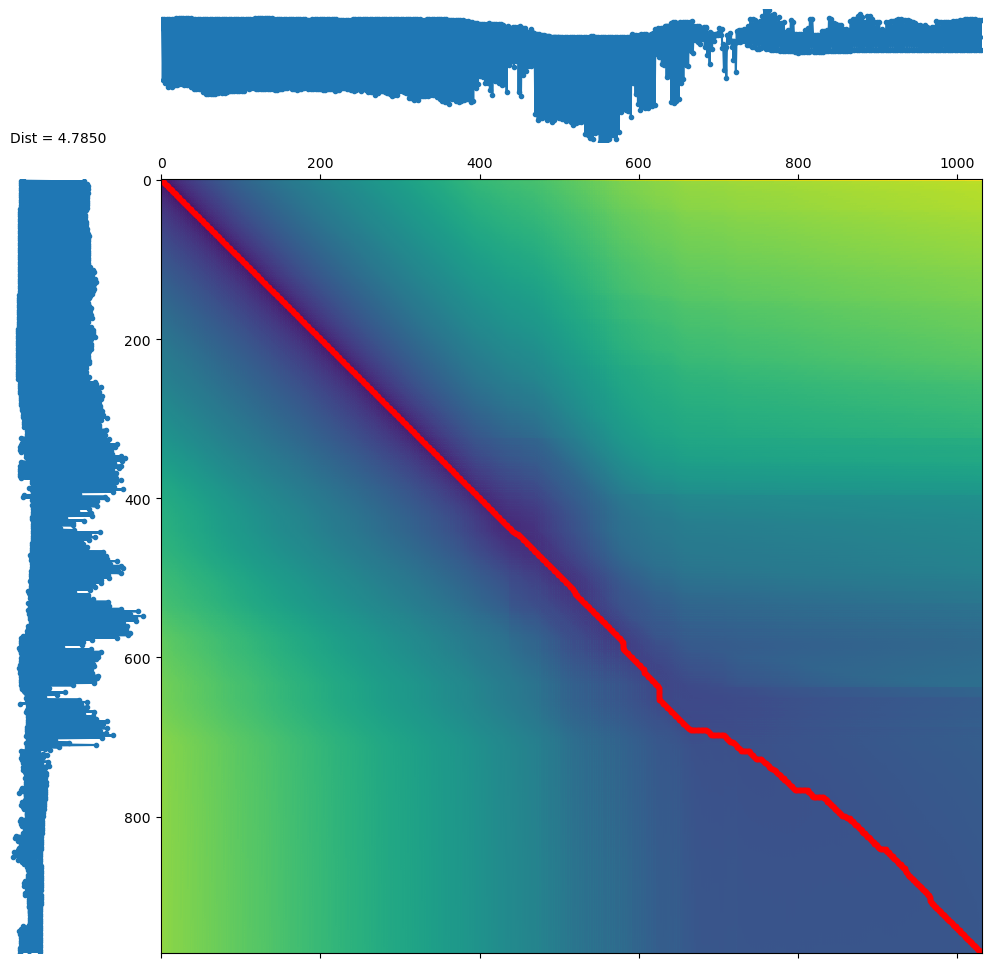

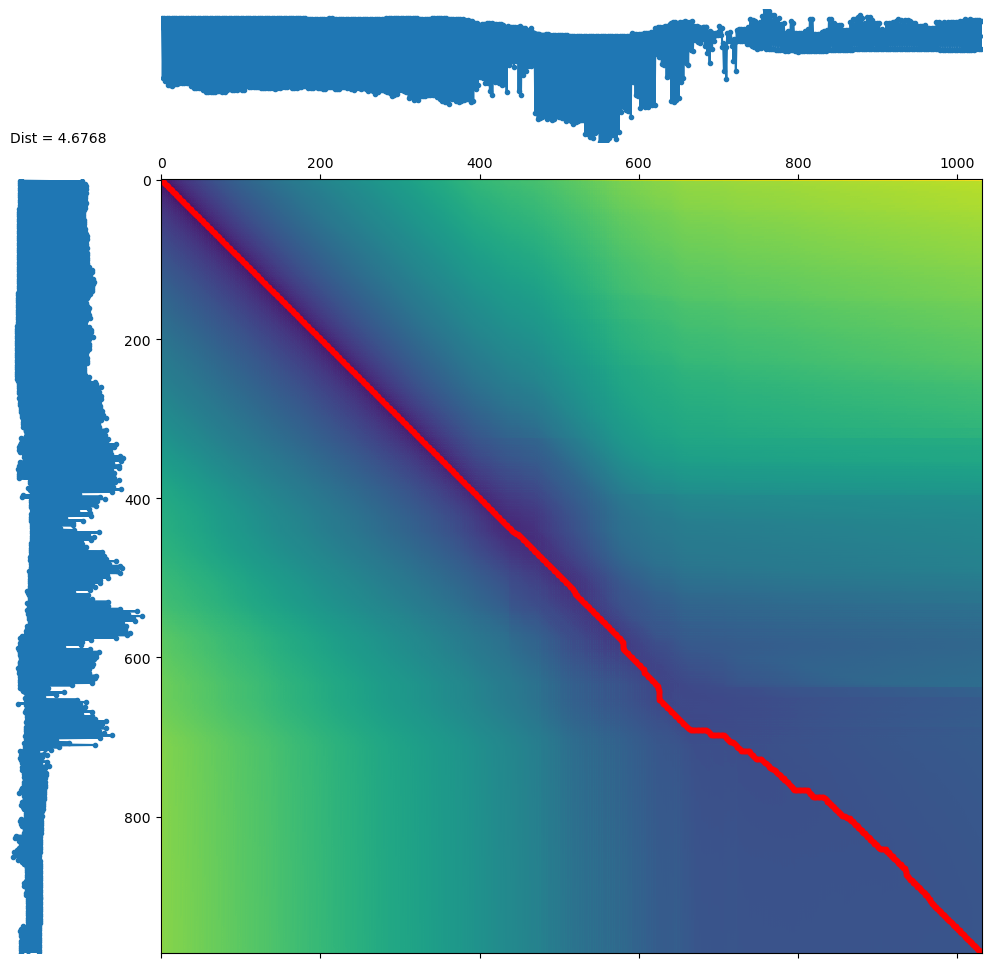

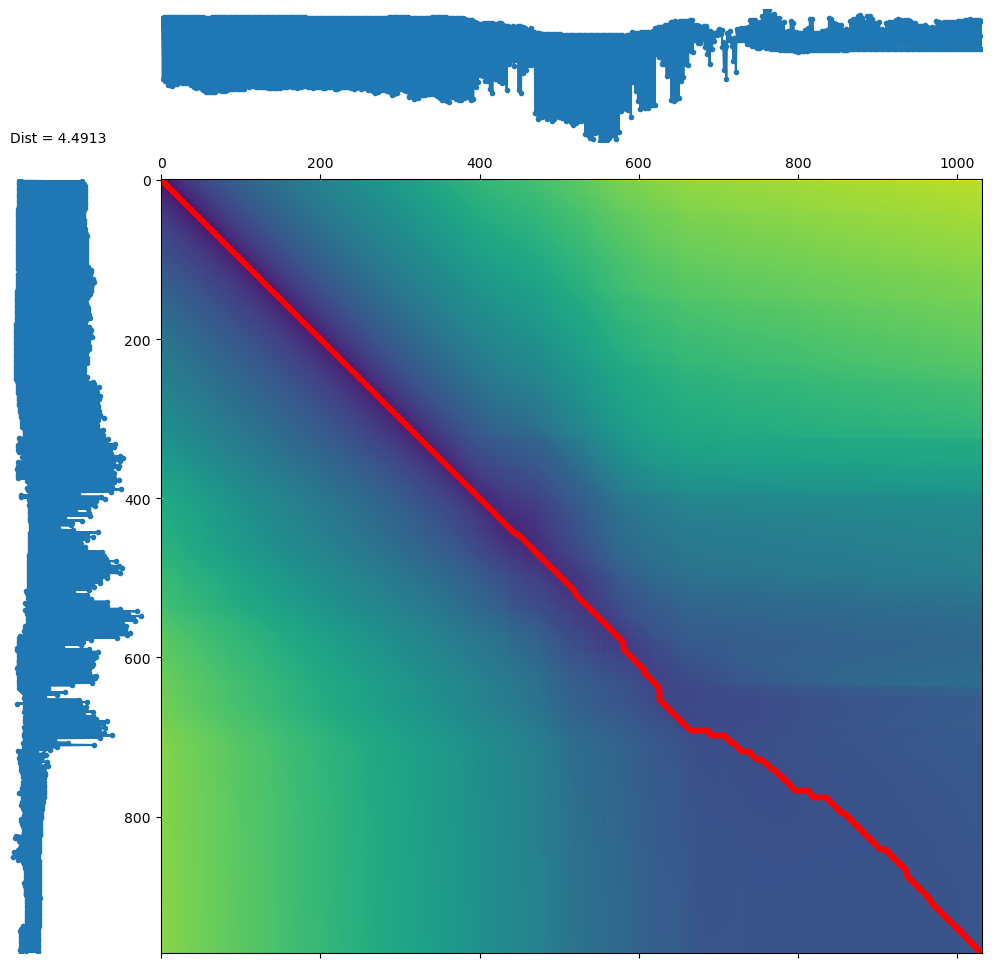

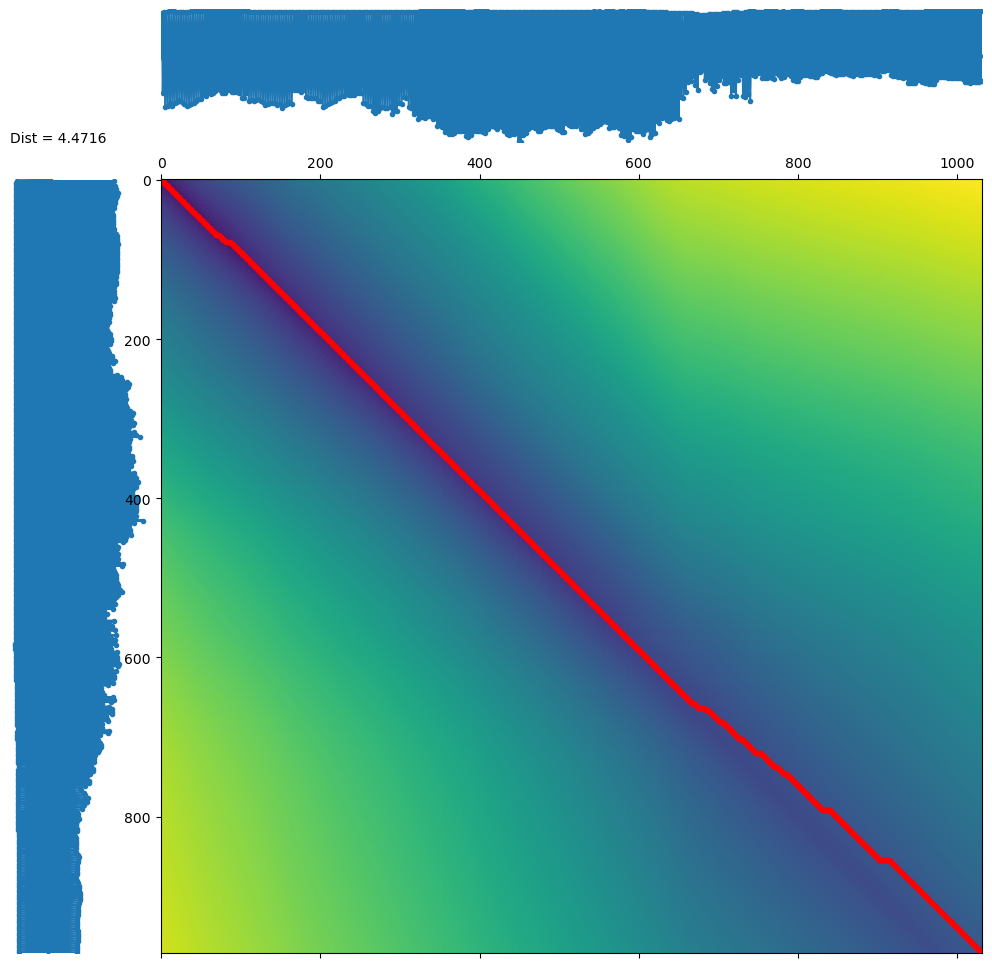

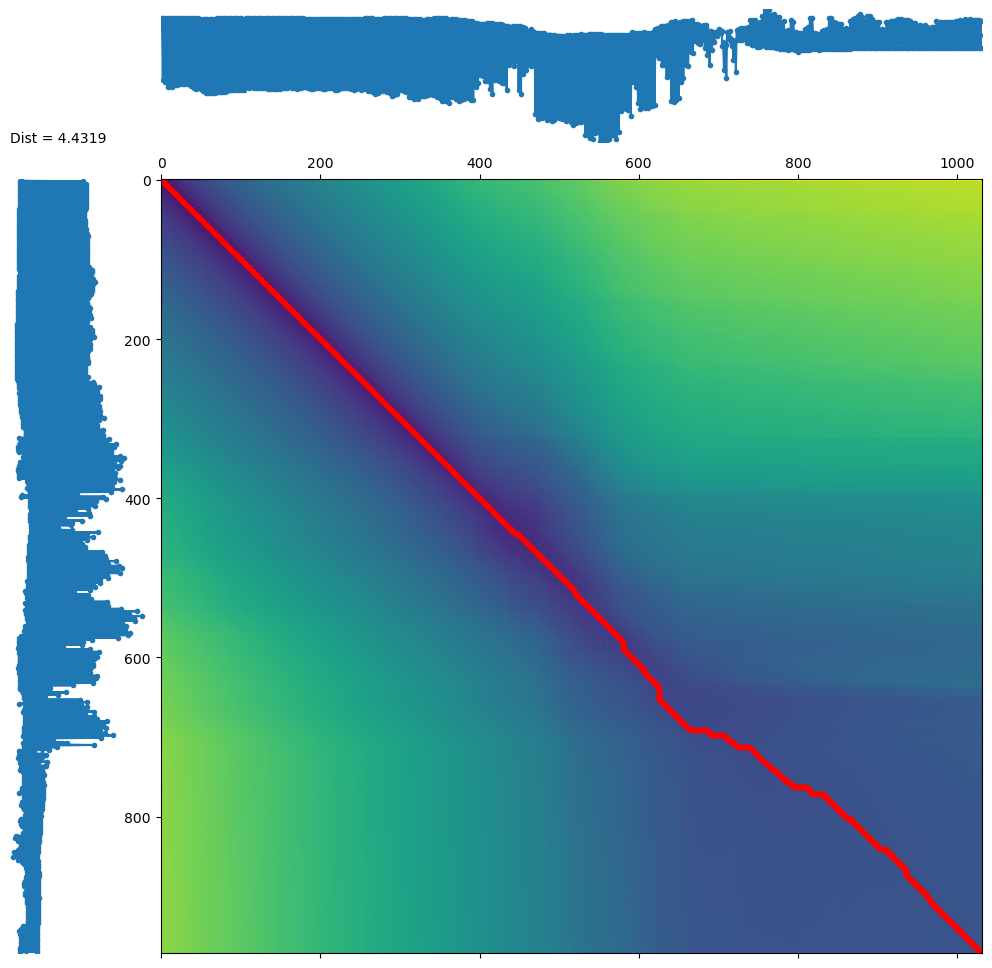

In [3]:
#########################################
# 假設 x_index 是排序後的前幾個索引
x_index = [i for i in range(min(5, len(x_distance)))]  # 取前五個，根據需要修改

# 可視化 DTW 路徑
for i in x_index:
    # 從排序後的 x_distance 中獲取 Landmark 和對應的路徑
    landmark, max_distance, paths = x_distance[i]

    # 從 model_data 和 test_data 中選擇相應的數據
    model_sequence = model_data[model_data['landmark'] == landmark][['x', 'y', 'z']].values
    test_sequence = test_data[test_data['landmark'] == landmark][['x', 'y', 'z']].values

    # 使用 dtwvis 可視化 DTW 路徑
    best_path = dtw.best_path(paths)
    dtwvis.plot_warpingpaths(model_sequence.flatten(), test_sequence.flatten(), paths, best_path)